## Feature Engineering Notebook

In [13]:
#imports
import pandas as pd
import sweetviz as sv
from sklearn.model_selection import train_test_split
import numpy as np
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.utils import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
import shap
from sklearn.model_selection import cross_val_predict

In [14]:
#read in and view training data
training = pd.read_csv("C:\\Users\\donya\\Documents\\GSB 545\\GSB-545\\train.csv")
training.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [15]:
#read in and view test data
test = pd.read_csv("C:\\Users\\donya\\Documents\\GSB 545\\GSB-545\\test.csv")
test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [16]:
#display summary statistics of quantitative variables in training data
training.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [17]:
#unique values for each category (courtesty of @wesleyhuan's notebook)
categorical_variables = training.select_dtypes(include=["str"]).columns.tolist()
for column in categorical_variables:
    print(column, ":", training[column].unique())

Soil_Type : <ArrowStringArray>
['Loamy', 'Clay', 'Sandy', 'Silt']
Length: 4, dtype: str
Crop_Type : <ArrowStringArray>
['Sugarcane', 'Wheat', 'Rice', 'Potato', 'Cotton', 'Maize']
Length: 6, dtype: str
Crop_Growth_Stage : <ArrowStringArray>
['Sowing', 'Vegetative', 'Flowering', 'Harvest']
Length: 4, dtype: str
Season : <ArrowStringArray>
['Zaid', 'Kharif', 'Rabi']
Length: 3, dtype: str
Irrigation_Type : <ArrowStringArray>
['Drip', 'Rainfed', 'Sprinkler', 'Canal']
Length: 4, dtype: str
Water_Source : <ArrowStringArray>
['Rainwater', 'River', 'Reservoir', 'Groundwater']
Length: 4, dtype: str
Mulching_Used : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Region : <ArrowStringArray>
['East', 'South', 'North', 'West', 'Central']
Length: 5, dtype: str
Irrigation_Need : <ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str


# Feature engineering

In [18]:
#make a copy of the original dataset and split data
training_fe = training.copy()

## Transformations of features (to fix skew)

In [20]:
#quick sweetviz visualizations to show original feature distributions
report = sv.analyze(training_fe)
report.show_html("hw4_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report hw4_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


The features are not very skewed. Transformations to fix skew of the features does not seem appropriate for this data.

After doing some research into the dataset and reviewing other Kaggle notebooks, it appears that a large amount of the feature engineering is defined using domain knowledge. Therfore, the following features have been created using outside research and examples from other Kaggle authors.

In [19]:
# Start off by one-hot encoding categorical variables
cat_columns = ['Soil_Type',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used',
 'Region']
training_fe = pd.get_dummies(training_fe, columns=cat_columns)*1
training_fe.head()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West
0,0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,...,1,0,0,1,0,0,1,0,0,0
1,1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,...,0,0,1,0,1,0,0,0,1,0
2,2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,...,0,1,0,0,1,0,0,1,0,0
3,3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,...,0,0,1,0,1,0,0,0,1,0
4,4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,...,0,0,1,1,0,0,0,0,1,0


In [20]:
# Transformed features

# Evapotranspiration proxy — heat + wind drives water loss
training_fe['Evapotranspiration_Index'] = training_fe['Temperature_C'] * training_fe['Wind_Speed_kmh'] / (training_fe['Humidity'] + 1)

# Soil water retention capacity
training_fe['Log_Soil_Moisture'] = np.log1p(training_fe['Soil_Moisture'])

# pH deviation from neutral (7.0) — stress indicator
training_fe['pH_Deviation'] = abs(training_fe['Soil_pH'] - 7.0)

# Soil health
training_fe['Soil_health'] = training_fe['Organic_Carbon']*training_fe['Soil_Moisture']/(training_fe['Electrical_Conductivity']+0.1)

# Total water input
training_fe['Total_water_input'] = training_fe['Rainfall_mm'] + training_fe['Previous_Irrigation_mm']

#Interactions

# Mulch interaction
training_fe['Mulch_moisture'] = training_fe['Soil_Moisture']*training_fe['Mulching_Used_Yes']

# Moisture retention
training_fe['Moisture_retention'] = training_fe['Soil_Moisture']*training_fe['Organic_Carbon']

# Soil moisture and temperature interaction
training_fe['moist_temp'] = training_fe['Soil_Moisture']*training_fe['Temperature_C']

# temperature and wind interaction
training_fe['temp_wind'] = training_fe['Temperature_C']*training_fe['Wind_Speed_kmh']

# temperature and humidity interaction
training_fe["temp_humidity"] = training_fe['Temperature_C']*training_fe['Humidity']

# Polynomials (squared predictors)

training_fe['Temp_Squared'] = training_fe['Temperature_C'] ** 2
training_fe['Wind_Squared'] = training_fe['Wind_Speed_kmh'] ** 2
training_fe['Moisture_Squared'] = training_fe['Soil_Moisture'] ** 2

#Polynomials (cubed predictors)
training_fe['Temp_Cubed'] = training_fe['Temperature_C'] ** 3
training_fe['Wind_Cubed'] = training_fe['Wind_Speed_kmh'] ** 3

In [21]:
training_fe.head()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Mulch_moisture,Moisture_retention,moist_temp,temp_wind,temp_humidity,Temp_Squared,Wind_Squared,Moisture_Squared,Temp_Cubed,Wind_Cubed
0,0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,...,0.00,32.9058,489.0258,252.0179,759.6561,225.3001,281.9041,1061.4564,3381.754501,4733.169839
1,1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,...,56.61,24.9084,1297.5012,77.6988,1555.3512,525.3264,11.4921,3204.6921,12040.481088,38.958219
2,2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,...,27.71,22.4451,747.3387,103.8345,2487.1734,727.3809,14.8225,767.8441,19617.462873,57.066625
3,3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,...,13.32,17.7156,177.4224,30.7692,820.1124,177.4224,5.3361,177.4224,2363.266368,12.326391
4,4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,...,0.00,22.4732,1195.8108,281.8668,1842.2442,408.8484,194.3236,3497.5396,8266.914648,2708.870984


In [22]:
X = training_fe.drop(["Irrigation_Need", "id"], axis=1)
y = training_fe["Irrigation_Need"]

# split data
X_train_fe, X_test_fe, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=321, stratify=y
)

In [23]:
#label encoding for XGBoost
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

# Check the mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [26]:
X.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Mulch_moisture,Moisture_retention,moist_temp,temp_wind,temp_humidity,Temp_Squared,Wind_Squared,Moisture_Squared,Temp_Cubed,Wind_Cubed
0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,0.82,...,0.00,32.9058,489.0258,252.0179,759.6561,225.3001,281.9041,1061.4564,3381.754501,4733.169839
1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,5.27,...,56.61,24.9084,1297.5012,77.6988,1555.3512,525.3264,11.4921,3204.6921,12040.481088,38.958219
2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,8.24,...,27.71,22.4451,747.3387,103.8345,2487.1734,727.3809,14.8225,767.8441,19617.462873,57.066625
3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,8.32,...,13.32,17.7156,177.4224,30.7692,820.1124,177.4224,5.3361,177.4224,2363.266368,12.326391
4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,7.37,...,0.00,22.4732,1195.8108,281.8668,1842.2442,408.8484,194.3236,3497.5396,8266.914648,2708.870984


In [27]:
y.head()

0       Low
1       Low
2       Low
3    Medium
4       Low
Name: Irrigation_Need, dtype: str

## Feature importance: Testing new feature set with baseline models

In [24]:
#define baseline models

#XGBoost baseline
xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,                 
    random_state=321
)

#LGBoost baseline
lgb_model = LGBMClassifier(
    objective='multiclass',
    num_class=3,        
    class_weight='balanced', 
    random_state=321
)

#Catboost baseline
catboost_model = CatBoostClassifier(
    loss_function='MultiClass',  # multiclass classification
    auto_class_weights='Balanced',  # handles imbalance automatically
    random_state=321,
    verbose=0
)

In [25]:
#define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=321)

In [27]:
#run baseline models with full engineered feature set - XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X_train_fe, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
print(cv_scores_xgb)
print(cv_scores_xgb.mean())
print(cv_scores_xgb.std())

xgb_model.fit(X_train_fe, y_train)

#evaluate final model performance on held out test set
y_pred = xgb_model.predict(X_test_fe)
print("XGBoost Baseline Balanced Accuracy Score (Full feature set):", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.96011765 0.96372276 0.96063684 0.95997259 0.96375133]
0.9616402330089638
0.0017262541565896032
XGBoost Baseline Balanced Accuracy Score (Full feature set): 0.96168316376228
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      4202
           1       0.99      0.99      0.99     73983
           2       0.98      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



In [28]:
#run baseline models with full engineered feature set - LGBoost
cv_scores_lgb = cross_val_score(lgb_model, X_train_fe, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
print(cv_scores_lgb)
print(cv_scores_lgb.mean())
print(cv_scores_lgb.std())

lgb_model.fit(X_train_fe, y_train)

#evaluate final model performance on held out test set
y_pred = lgb_model.predict(X_test_fe)
print("LGBoost Baseline Balanced Accuracy Score (Full feature set):", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.96881394 0.9696721  0.96907882 0.96769427 0.96924038]
0.9688999022593752
0.0006641040376586555
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.079013 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6529
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 58
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LGBoost Baseline Balanced Accuracy Score (Full feature set): 0.9676428359167676
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      4202
           1       0.99      0.99      0.99     73983
           2       0.99      0.96      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.94      0.97      0.95    126000
weighted avg       0.

In [29]:
#run baseline models with full engineered feature set - Catboost

#need to use manual fold loop because of cloning error
cv_scores_cb_baseline = []

for train_idx, val_idx in cv.split(X_train_fe, y_train):
    X_fold_train, X_fold_val = X_train_fe.iloc[train_idx], X_train_fe.iloc[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]  # numpy indexing

    catboost_model.fit(X_fold_train, y_fold_train)

    y_pred_fold = catboost_model.predict(X_fold_val)

    cv_scores_cb_baseline.append(balanced_accuracy_score(y_fold_val, y_pred_fold))

print(cv_scores_cb_baseline)
print(np.mean(cv_scores_cb_baseline))
print(np.std(cv_scores_cb_baseline))

catboost_model.fit(X_train_fe, y_train)

# Evaluate final model performance on held out test set
y_pred = catboost_model.predict(X_test_fe)
print("CatBoost Balanced Accuracy Score:", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.9679574392813276, 0.9692085080426645, 0.9692421854375107, 0.9672186770099608, 0.9685416067881566]
0.9684336833119239
0.0007705485341828167
CatBoost Balanced Accuracy Score: 0.9674669258810166
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      4202
           1       0.99      0.99      0.99     73983
           2       0.99      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.95      0.97      0.96    126000
weighted avg       0.98      0.98      0.98    126000



## Feature importance: Selecting the most important features using feature importance, permutation importance, and SHAP

Feature importance and permutation importance

In [30]:
# Rank and display feature importances from baseline models using feature data
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)
lgb_importances = pd.Series(lgb_model.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)
catboost_importances = pd.Series(catboost_model.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)
print("Top 10 XGBoost Feature Importances:")
print(xgb_importances.head(10))
print("\nTop 10 LG Boost Feature Importances:")
print(lgb_importances.head(10))
print("\nTop 10 CatBoost Feature Importances:")
print(catboost_importances.head(10))

Top 10 XGBoost Feature Importances:
Crop_Growth_Stage_Vegetative    0.224333
Crop_Growth_Stage_Flowering     0.152644
Mulching_Used_No                0.142692
Crop_Growth_Stage_Sowing        0.119315
Soil_Moisture                   0.091154
Crop_Growth_Stage_Harvest       0.088820
Temperature_C                   0.041689
Wind_Speed_kmh                  0.036114
Mulch_moisture                  0.034395
temp_wind                       0.022703
dtype: float32

Top 10 LG Boost Feature Importances:
Rainfall_mm                  982
Temperature_C                865
Soil_Moisture                758
Wind_Speed_kmh               664
Mulching_Used_No             509
Crop_Growth_Stage_Harvest    479
Total_water_input            457
Crop_Growth_Stage_Sowing     455
Previous_Irrigation_mm       426
Humidity                     368
dtype: int32

Top 10 CatBoost Feature Importances:
Soil_Moisture                10.299988
Crop_Growth_Stage_Harvest     9.671923
Crop_Growth_Stage_Sowing      8.275547
Moi

In [31]:
# Rank and display permutation importances for baseline models

xgb_perm_importance = permutation_importance(xgb_model, X_test_fe, y_test, n_repeats=10, random_state=321)
lgb_perm_importance = permutation_importance(lgb_model, X_test_fe, y_test, n_repeats=10, random_state=321)
catboost_perm_importance = permutation_importance(catboost_model, X_test_fe, y_test, n_repeats=10, random_state=321)

# saving permutation importance results in DataFrames for easier display
xgb_perm_importance_df = pd.DataFrame({
    'feature': X_test_fe.columns,
    'importance_mean': xgb_perm_importance.importances_mean,
    'importance_std': xgb_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

lgb_perm_importance_df = pd.DataFrame({
    'feature': X_test_fe.columns,
    'importance_mean': lgb_perm_importance.importances_mean,
    'importance_std': lgb_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

catboost_perm_importance_df = pd.DataFrame({
    'feature': X_test_fe.columns,
    'importance_mean': catboost_perm_importance.importances_mean,
    'importance_std': catboost_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

# display top 10 features by permutation importance for both models
print("Top 10 XGBoost Permutation Importances:")
print(xgb_perm_importance_df.head(10))
print("\nTop 10 LG Boost Permutation Importances:")
print(lgb_perm_importance_df.head(10))
print("\nTop 10 CatBoost Permutation Importances:")
print(catboost_perm_importance_df.head(10))

Top 10 XGBoost Permutation Importances:
                         feature  importance_mean  importance_std
1                  Soil_Moisture         0.177752        0.000519
22     Crop_Growth_Stage_Harvest         0.115097        0.000390
4                  Temperature_C         0.108729        0.000604
8                 Wind_Speed_kmh         0.105721        0.000766
23      Crop_Growth_Stage_Sowing         0.098544        0.000292
36              Mulching_Used_No         0.067754        0.000303
48                Mulch_moisture         0.046909        0.000453
21   Crop_Growth_Stage_Flowering         0.016187        0.000211
24  Crop_Growth_Stage_Vegetative         0.014910        0.000329
6                    Rainfall_mm         0.009532        0.000148

Top 10 LG Boost Permutation Importances:
                         feature  importance_mean  importance_std
1                  Soil_Moisture         0.172455        0.000573
22     Crop_Growth_Stage_Harvest         0.127068        0.0

In [32]:
# XGBoost averaged rankings
xgb_feat_df = pd.DataFrame({
    "feature": X_train_fe.columns,
    "feat_importance": xgb_model.feature_importances_
})

#rank feature importance and permutation importance results
xgb_feat_df["rank_feat"] = xgb_feat_df["feat_importance"].rank(ascending=False)
xgb_perm_importance_df["rank_perm"] = xgb_perm_importance_df["importance_mean"].rank(ascending=False)

#merge
xgb_combined = (
    xgb_feat_df
    .merge(xgb_perm_importance_df[["feature", "importance_mean", "rank_perm"]], on="feature")
)

#average ranks
xgb_combined["rank_avg"] = (xgb_combined["rank_feat"] + xgb_combined["rank_perm"]) / 2

#sort and display top 30 features
xgb_combined = xgb_combined.sort_values("rank_avg")
xgb_top_features = xgb_combined.head(30)
xgb_top_features

,feature,feat_importance,rank_feat,importance_mean,rank_perm,rank_avg
1,Soil_Moisture,0.091154,5.0,0.177752,1.0,3.00
22,Crop_Growth_Stage_Harvest,0.088820,6.0,0.115097,2.0,4.00
23,Crop_Growth_Stage_Sowing,0.119315,4.0,0.098544,5.0,4.50
36,Mulching_Used_No,0.142692,3.0,0.067754,6.0,4.50
24,Crop_Growth_Stage_Vegetative,0.224333,1.0,0.014910,9.0,5.00
21,Crop_Growth_Stage_Flowering,0.152644,2.0,0.016187,8.0,5.00
4,Temperature_C,0.041689,7.0,0.108729,3.0,5.00
8,Wind_Speed_kmh,0.036114,8.0,0.105721,4.0,6.00
48,Mulch_moisture,0.034395,9.0,0.046909,7.0,8.00
6,Rainfall_mm,0.014428,11.0,0.009532,10.0,10.50


In [33]:
# LG Boost averaged rankings
lgb_feat_df = pd.DataFrame({
    "feature": X_train_fe.columns,
    "feat_importance": lgb_model.feature_importances_
})

#rank feature importance and permutation importance results
lgb_feat_df["rank_feat"] = lgb_feat_df["feat_importance"].rank(ascending=False)
lgb_perm_importance_df["rank_perm"] = lgb_perm_importance_df["importance_mean"].rank(ascending=False)

#merge
lgb_combined = (
    lgb_feat_df
    .merge(lgb_perm_importance_df[["feature", "importance_mean", "rank_perm"]], on="feature")
)

#average ranks
lgb_combined["rank_avg"] = (lgb_combined["rank_feat"] + lgb_combined["rank_perm"]) / 2

#sort and display top 30 features
lgb_combined = lgb_combined.sort_values("rank_avg")
lgb_top_features = lgb_combined.head(30)
lgb_top_features

,feature,feat_importance,rank_feat,importance_mean,rank_perm,rank_avg
1,Soil_Moisture,758,3.0,0.172455,1.0,2.00
4,Temperature_C,865,2.0,0.104213,4.0,3.00
22,Crop_Growth_Stage_Harvest,479,6.0,0.127068,2.0,4.00
8,Wind_Speed_kmh,664,4.0,0.102549,5.0,4.50
23,Crop_Growth_Stage_Sowing,455,8.0,0.109130,3.0,5.50
6,Rainfall_mm,982,1.0,0.010835,10.0,5.50
36,Mulching_Used_No,509,5.0,0.067440,6.0,5.50
48,Mulch_moisture,363,11.0,0.051924,7.0,9.00
47,Total_water_input,457,7.0,0.001905,12.0,9.50
51,temp_wind,310,12.0,0.003929,11.0,11.50


Immediately reducing catboost model feature set to 20 features since SHAP analysis kept crashing.

In [34]:
# CatBoost averaged rankings
catboost_feat_df = pd.DataFrame({
    "feature": X_train_fe.columns,
    "feat_importance": catboost_model.feature_importances_
})

#rank feature importance and permutation importance results
catboost_feat_df["rank_feat"] = catboost_feat_df["feat_importance"].rank(ascending=False)
catboost_perm_importance_df["rank_perm"] = catboost_perm_importance_df["importance_mean"].rank(ascending=False)

#merge
catboost_combined = (
    catboost_feat_df
    .merge(catboost_perm_importance_df[["feature", "importance_mean", "rank_perm"]], on="feature")
)

#average ranks
catboost_combined["rank_avg"] = (catboost_combined["rank_feat"] + catboost_combined["rank_perm"]) / 2

#sort and display top 20 features
catboost_combined = catboost_combined.sort_values("rank_avg")
catboost_top_features = catboost_combined.head(20)
catboost_top_features

,feature,feat_importance,rank_feat,importance_mean,rank_perm,rank_avg
22,Crop_Growth_Stage_Harvest,9.671923,2.0,0.146033,1.0,1.5
1,Soil_Moisture,10.299988,1.0,0.032671,3.0,2.0
23,Crop_Growth_Stage_Sowing,8.275547,3.0,0.125928,2.0,2.5
55,Moisture_Squared,6.963637,4.0,0.020432,7.0,5.5
48,Mulch_moisture,4.118781,7.0,0.032433,4.0,5.5
6,Rainfall_mm,6.463213,5.0,0.006307,10.0,7.5
8,Wind_Speed_kmh,3.196404,12.0,0.028622,5.0,8.5
53,Temp_Squared,3.334229,9.0,0.018653,8.0,8.5
36,Mulching_Used_No,3.146979,13.0,0.025947,6.0,9.5
47,Total_water_input,3.739586,8.0,0.005612,12.0,10.0


In [35]:
#Extra trees reduced dataset (top 30 features)
X_train_xgb_30 = X_train_fe[xgb_top_features["feature"]]
X_test_xgb_30 = X_test_fe[xgb_top_features["feature"]]

#LG Boost reduced dataset (top 30 features)
X_train_lgb_30 = X_train_fe[lgb_top_features["feature"]]
X_test_lgb_30 = X_test_fe[lgb_top_features["feature"]]

#CatBoost reduced dataset (top 20 features)
X_train_cb_20 = X_train_fe[catboost_top_features["feature"]]
X_test_cb_20 = X_test_fe[catboost_top_features["feature"]]

In [36]:
#run baseline models with reduced feature set - XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X_train_xgb_30, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
print(cv_scores_xgb)
print(cv_scores_xgb.mean())
print(cv_scores_xgb.std())

xgb_model.fit(X_train_xgb_30, y_train)

#evaluate final model performance on held out test set
y_pred = xgb_model.predict(X_test_xgb_30)
print("XGBoost Baseline Balanced Accuracy Score (Reduced feature set 1):", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.96059972 0.96302799 0.96118323 0.95949843 0.96332914]
0.9615277002476622
0.0014555942731343898
XGBoost Baseline Balanced Accuracy Score (Reduced feature set 1): 0.9607765588628278
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      4202
           1       0.99      0.99      0.99     73983
           2       0.98      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



In [37]:
#run baseline models with reduced feature set - LGBoost
cv_scores_lgb = cross_val_score(lgb_model, X_train_lgb_30, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
print(cv_scores_lgb)
print(cv_scores_lgb.mean())
print(cv_scores_lgb.std())

lgb_model.fit(X_train_lgb_30, y_train)

#evaluate final model performance on held out test set
y_pred = lgb_model.predict(X_test_lgb_30)
print("LGBoost Baseline Balanced Accuracy Score (Reduced feature set 1):", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.96914171 0.9700726  0.96957264 0.96813792 0.96835262]
0.9690554978599477
0.0007273699580979015
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051279 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4226
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 30
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LGBoost Baseline Balanced Accuracy Score (Reduced feature set 1): 0.9676073762566654
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      4202
           1       0.99      0.99      0.99     73983
           2       0.99      0.96      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.94      0.97      0.96    126000
weighted avg    

In [ ]:
#run baseline models with reduced feature set - Catboost

#need to use manual fold loop because of cloning error
cv_scores_cb_baseline = []

for train_idx, val_idx in cv.split(X_train_cb_20, y_train):
    X_fold_train, X_fold_val = X_train_cb_20.iloc[train_idx], X_train_cb_20.iloc[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]  # numpy indexing

    catboost_model.fit(X_fold_train, y_fold_train)

    y_pred_fold = catboost_model.predict(X_fold_val)

    cv_scores_cb_baseline.append(balanced_accuracy_score(y_fold_val, y_pred_fold))

print(cv_scores_cb_baseline)
print(np.mean(cv_scores_cb_baseline))
print(np.std(cv_scores_cb_baseline))

catboost_model.fit(X_train_cb_20, y_train)

# Evaluate final model performance on held out test set
y_pred = catboost_model.predict(X_test_cb_20)
print("CatBoost Balanced Accuracy Score:", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.9678142887206067, 0.9700363215717017, 0.9685153514270577, 0.9673581616739458, 0.9685770763651425]
0.9684602399516908
0.000909126043888081
CatBoost Balanced Accuracy Score: 0.9680962201847642
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4202
           1       0.99      0.99      0.99     73983
           2       0.99      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.95      0.97      0.96    126000
weighted avg       0.98      0.98      0.98    126000



SHAP: XGBoost and LG Boost only (for reduction of feature set to 20 features)

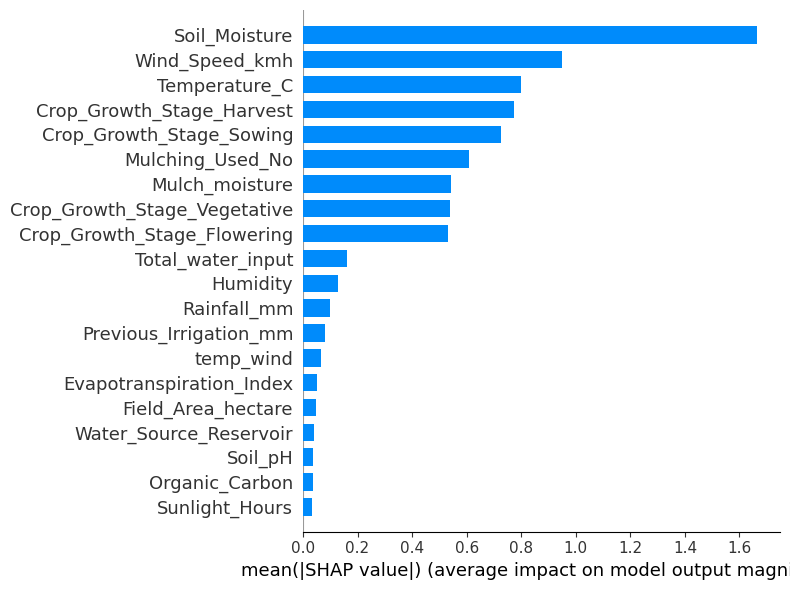

Top 20 features by SHAP:
['Soil_Moisture', 'Wind_Speed_kmh', 'Temperature_C', 'Crop_Growth_Stage_Harvest', 'Crop_Growth_Stage_Sowing', 'Mulching_Used_No', 'Mulch_moisture', 'Crop_Growth_Stage_Vegetative', 'Crop_Growth_Stage_Flowering', 'Total_water_input', 'Humidity', 'Rainfall_mm', 'Previous_Irrigation_mm', 'temp_wind', 'Evapotranspiration_Index', 'Field_Area_hectare', 'Water_Source_Reservoir', 'Soil_pH', 'Organic_Carbon', 'Sunlight_Hours']

X_train_xgb_20 shape: (504000, 20)
X_test_xgb_20 shape:  (126000, 20)


In [39]:
# XGBoost SHAP values on test set
# XGBoost SHAP values on test set
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_vals = xgb_explainer.shap_values(X_test_xgb_30)

# Handle all shape cases: list, 3D array, or already 2D
if isinstance(xgb_shap_vals, list):
    # Older SHAP: list of arrays, one per class → take class 1
    xgb_shap_vals = xgb_shap_vals[1]
elif xgb_shap_vals.ndim == 3:
    # Newer SHAP: shape (n_samples, n_features, n_classes) → take class 1
    xgb_shap_vals = xgb_shap_vals[:, :, 1]
# else: already (n_samples, n_features), nothing to do

# Confirm it's now 2D
assert xgb_shap_vals.ndim == 2, f"Expected 2D SHAP array, got shape {xgb_shap_vals.shape}"

# Global feature importance bar plot
shap.summary_plot(
    xgb_shap_vals,
    X_test_xgb_30,
    plot_type="bar",
    plot_size=(8, 6)
)

# Top 20 features by mean absolute SHAP value
xgb_shap_importance = pd.DataFrame({
    "feature": X_test_xgb_30.columns,
    "shap_mean_abs": np.abs(xgb_shap_vals).mean(axis=0)  # now guaranteed 1D
}).sort_values("shap_mean_abs", ascending=False)

xgb_top20_features = xgb_shap_importance.head(20)["feature"].tolist()
print("Top 20 features by SHAP:")
print(xgb_top20_features)

# Reduce X_train and X_test to top 20 features
X_train_xgb_20 = X_train_xgb_30[xgb_top20_features]
X_test_xgb_20  = X_test_xgb_30[xgb_top20_features]  # fixed: was X_test_lgb_20

print(f"\nX_train_xgb_20 shape: {X_train_xgb_20.shape}")
print(f"X_test_xgb_20 shape:  {X_test_xgb_20.shape}")

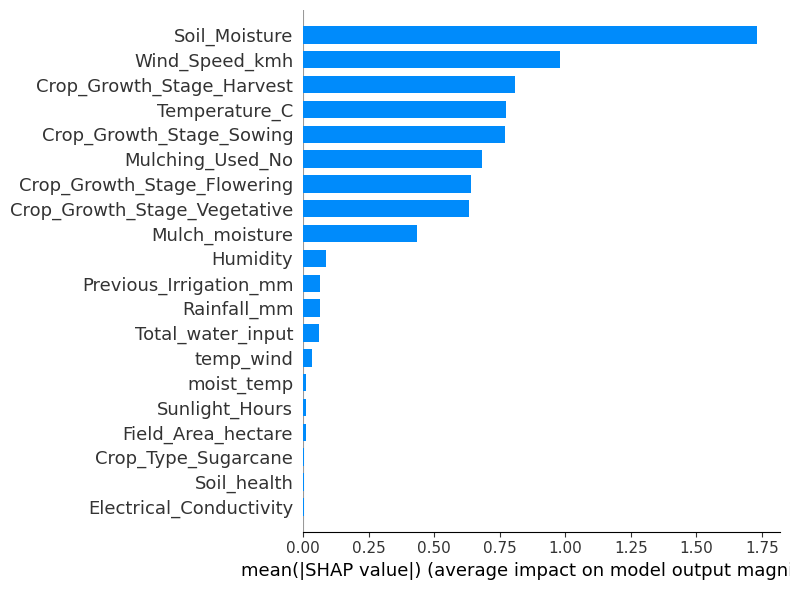

Top 20 features by SHAP:
['Soil_Moisture', 'Wind_Speed_kmh', 'Crop_Growth_Stage_Harvest', 'Temperature_C', 'Crop_Growth_Stage_Sowing', 'Mulching_Used_No', 'Crop_Growth_Stage_Flowering', 'Crop_Growth_Stage_Vegetative', 'Mulch_moisture', 'Humidity', 'Previous_Irrigation_mm', 'Rainfall_mm', 'Total_water_input', 'temp_wind', 'moist_temp', 'Sunlight_Hours', 'Field_Area_hectare', 'Crop_Type_Sugarcane', 'Soil_health', 'Electrical_Conductivity']

X_train_lgb_20 shape: (504000, 20)
X_test_lgb_20 shape:  (126000, 20)


In [40]:
# LightGBM SHAP values on test set
lgb_explainer = shap.TreeExplainer(lgb_model)
lgb_shap_vals = lgb_explainer.shap_values(X_test_lgb_30)

# Handle all shape cases: list, 3D array, or already 2D
if isinstance(lgb_shap_vals, list):
    # Older SHAP: list of arrays, one per class → take class 1
    lgb_shap_vals = lgb_shap_vals[1]
elif lgb_shap_vals.ndim == 3:
    # Newer SHAP: shape (n_samples, n_features, n_classes) → take class 1
    lgb_shap_vals = lgb_shap_vals[:, :, 1]
# else: already (n_samples, n_features), nothing to do

# Confirm it's now 2D
assert lgb_shap_vals.ndim == 2, f"Expected 2D SHAP array, got shape {lgb_shap_vals.shape}"

# Global feature importance bar plot
shap.summary_plot(
    lgb_shap_vals,
    X_test_lgb_30,  # fixed: was X_test_lgb_50
    plot_type="bar",
    plot_size=(8, 6)
)

# Top 20 features by mean absolute SHAP value
lgb_shap_importance = pd.DataFrame({
    "feature": X_test_lgb_30.columns,  # fixed: was X_test_lgb_50
    "shap_mean_abs": np.abs(lgb_shap_vals).mean(axis=0)
}).sort_values("shap_mean_abs", ascending=False)

lgb_top20_features = lgb_shap_importance.head(20)["feature"].tolist()
print("Top 20 features by SHAP:")
print(lgb_top20_features)

# Reduce X_train and X_test to top 20 features
X_train_lgb_20 = X_train_lgb_30[lgb_top20_features]  # fixed: was X_train_lgb_50
X_test_lgb_20  = X_test_lgb_30[lgb_top20_features]   # fixed: was X_test_lgb_50

print(f"\nX_train_lgb_20 shape: {X_train_lgb_20.shape}")
print(f"X_test_lgb_20 shape:  {X_test_lgb_20.shape}")

In [41]:
#run baseline models with final reduced feature set - XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X_train_xgb_20, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
print(cv_scores_xgb)
print(cv_scores_xgb.mean())
print(cv_scores_xgb.std())

xgb_model.fit(X_train_xgb_20, y_train)

#evaluate final model performance on held out test set
y_pred = xgb_model.predict(X_test_xgb_20)
print("XGBoost Baseline Balanced Accuracy Score (Final Reduced feature set):", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.96152207 0.96318638 0.96041418 0.96033358 0.96369087]
0.9618294156928794
0.0013886147958015018
XGBoost Baseline Balanced Accuracy Score (Final Reduced feature set): 0.9613747069745952
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      4202
           1       0.99      0.99      0.99     73983
           2       0.98      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



In [42]:
#run baseline models with final reduced feature set - LGBoost
cv_scores_lgb = cross_val_score(lgb_model, X_train_lgb_20, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
print(cv_scores_lgb)
print(cv_scores_lgb.mean())
print(cv_scores_lgb.std())

lgb_model.fit(X_train_lgb_20, y_train)

#evaluate final model performance on held out test set
y_pred = lgb_model.predict(X_test_lgb_20)
print("LGBoost Baseline Balanced Accuracy Score (Final Reduced feature set):", balanced_accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

[0.96937901 0.96939603 0.96876742 0.9677357  0.96860661]
0.9687769548335228
0.0006097602073838387
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033776 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 20
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LGBoost Baseline Balanced Accuracy Score (Final Reduced feature set): 0.9674888639348694
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      4202
           1       0.99      0.99      0.99     73983
           2       0.99      0.96      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.94      0.97      0.95    126000
weighted avg

## Model tuning

In [43]:
# XGBoost model tuning with final reduced feature set
def objective(trial):
    max_depth = trial.suggest_int('max_depth', 3, 15)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)

    xgb_optuna = XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        random_state=321,
        verbosity=0,
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        n_jobs=-1
    )

    cv_scores = cross_val_score(xgb_optuna, X_train_xgb_20, y_train, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    return cv_scores.mean()

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f'Best XGBoost parameters from Optuna: {xgb_study.best_params}')
print(f'Best XGBoost Balanced Accuracy score from Optuna: {xgb_study.best_value}')

best_xgb = XGBClassifier(
    **xgb_study.best_params,
    objective='multi:softprob',
    num_class=3,
    random_state=321,
    verbosity=0,
    n_jobs=-1
)
best_xgb.fit(X_train_xgb_20, y_train)
xgb_preds_tuned = best_xgb.predict(X_test_xgb_20)
print("XGBoost Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_tuned))
print("XGBoost Tuned (20 Features) Classification Report:\n", classification_report(y_test, xgb_preds_tuned))



[I 2026-04-30 07:04:13,823] A new study created in memory with name: no-name-4afa471c-3530-4c4e-be46-696ee2314fe0


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-30 07:05:28,318] Trial 0 finished with value: 0.9600748562985133 and parameters: {'max_depth': 10, 'learning_rate': 0.09316161077418342, 'n_estimators': 158, 'subsample': 0.9986454874945341, 'colsample_bytree': 0.5845008083685277}. Best is trial 0 with value: 0.9600748562985133.
[I 2026-04-30 07:06:13,304] Trial 1 finished with value: 0.960993258360984 and parameters: {'max_depth': 5, 'learning_rate': 0.1165511563845613, 'n_estimators': 150, 'subsample': 0.5933167089663205, 'colsample_bytree': 0.5305845104619236}. Best is trial 1 with value: 0.960993258360984.
[I 2026-04-30 07:07:32,695] Trial 2 finished with value: 0.9445114633682955 and parameters: {'max_depth': 13, 'learning_rate': 0.03061615580140383, 'n_estimators': 101, 'subsample': 0.9132342018354058, 'colsample_bytree': 0.5390762706189469}. Best is trial 1 with value: 0.960993258360984.
[I 2026-04-30 07:08:44,498] Trial 3 finished with value: 0.9608893388524089 and parameters: {'max_depth': 8, 'learning_rate': 0.1562

In [44]:
# LG Boost model tuning with final reduced feature set
def objective(trial):
    num_leaves = trial.suggest_int('num_leaves', 10, 200)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log = True)
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    reg_alpha = trial.suggest_float("reg_alpha", 1e-3, 10.0, log = True)
    reg_lambda = trial.suggest_float("reg_lambda", 1e-3, 10.0, log = True)
    
    lgbm_optuna = LGBMClassifier(
        random_state = 321, 
        class_weight='balanced', 
        objective="multiclass", 
        num_class = 3, 
        verbose = -1, 
        num_leaves=num_leaves, 
        max_depth=max_depth, 
        learning_rate=learning_rate, 
        n_estimators=n_estimators, 
        reg_alpha=reg_alpha,
        n_jobs = -1,
        reg_lambda=reg_lambda
        )
    
    cv_scores = cross_val_score(lgbm_optuna, X_train_lgb_20, y_train, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    return cv_scores.mean()

lgb_study = optuna.create_study(direction='maximize')
lgb_study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f'Best LG Boost parameters from Optuna: {lgb_study.best_params}')
print(f'Best LG Boost Balanced Accuracy score from Optuna: {lgb_study.best_value}')

best_lgb = LGBMClassifier(
    **lgb_study.best_params,
    random_state=321,
    verbose=-1,
    n_jobs=-1,
    class_weight = "balanced",
    objective = "multiclass",
    num_class = 3
)
best_lgb.fit(X_train_lgb_20, y_train)
lgb_preds_tuned = best_lgb.predict(X_test_lgb_20)
print("LightGBM Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, lgb_preds_tuned))
print("LightGBM Tuned (20 Features) Classification Report:\n", classification_report(y_test, lgb_preds_tuned))

[I 2026-04-30 07:38:34,079] A new study created in memory with name: no-name-2dd66f73-0919-44a2-afa4-fa5256121bd7


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-30 07:40:02,858] Trial 0 finished with value: 0.9668717043480382 and parameters: {'num_leaves': 37, 'max_depth': 14, 'learning_rate': 0.010930723427342491, 'n_estimators': 404, 'reg_alpha': 3.0311391989777183, 'reg_lambda': 3.7289516544769232}. Best is trial 0 with value: 0.9668717043480382.
[I 2026-04-30 07:40:35,976] Trial 1 finished with value: 0.9654582442508104 and parameters: {'num_leaves': 96, 'max_depth': 14, 'learning_rate': 0.23678640190246703, 'n_estimators': 117, 'reg_alpha': 0.014143709369149023, 'reg_lambda': 0.15342705003854898}. Best is trial 0 with value: 0.9668717043480382.
[I 2026-04-30 07:41:01,245] Trial 2 finished with value: 0.9685173607466933 and parameters: {'num_leaves': 61, 'max_depth': 13, 'learning_rate': 0.0898281450618939, 'n_estimators': 92, 'reg_alpha': 0.11967935496544001, 'reg_lambda': 2.854665084302293}. Best is trial 2 with value: 0.9685173607466933.
[I 2026-04-30 07:42:18,937] Trial 3 finished with value: 0.965651720540907 and parameters

In [45]:
# CatBoost model tuning with final reduced feature set
def objective(trial):
    iterations = trial.suggest_int('iterations', 100, 500)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    depth = trial.suggest_int('depth', 4, 10)
    l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1, 10, log=True)

    catboost_optuna = CatBoostClassifier(
        random_state=321,
        loss_function="MultiClass",
        auto_class_weights="Balanced",
        verbose=0,
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg
    )

    fold_scores = []
    for train_idx, val_idx in cv.split(X_train_cb_20, y_train):
        X_fold_train, X_fold_val = X_train_cb_20.iloc[train_idx], X_train_cb_20.iloc[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        catboost_optuna.fit(X_fold_train, y_fold_train)
        y_pred_fold = catboost_optuna.predict(X_fold_val)
        fold_scores.append(balanced_accuracy_score(y_fold_val, y_pred_fold))

    return np.mean(fold_scores)

cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f'Best CatBoost parameters from Optuna: {cat_study.best_params}')
print(f'Best CatBoost Balanced Accuracy score from Optuna: {cat_study.best_value}')

best_cat = CatBoostClassifier(
    **cat_study.best_params,
    random_state=321,
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    verbose=0
)
best_cat.fit(X_train_cb_20, y_train)
cat_preds_tuned = best_cat.predict(X_test_cb_20)
print("CatBoost Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, cat_preds_tuned))
print("CatBoost Tuned (20 Features) Classification Report:\n", classification_report(y_test, cat_preds_tuned))


[I 2026-04-30 08:00:24,943] A new study created in memory with name: no-name-0bcadef5-42cf-4c85-afb8-2d57988f8870


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-30 08:01:01,775] Trial 0 finished with value: 0.9635640076189054 and parameters: {'iterations': 101, 'learning_rate': 0.06325507300784544, 'depth': 4, 'l2_leaf_reg': 2.90421207516305}. Best is trial 0 with value: 0.9635640076189054.
[I 2026-04-30 08:02:31,361] Trial 1 finished with value: 0.9639024645672094 and parameters: {'iterations': 225, 'learning_rate': 0.022521499423953827, 'depth': 5, 'l2_leaf_reg': 6.356636097994175}. Best is trial 1 with value: 0.9639024645672094.
[I 2026-04-30 08:08:03,865] Trial 2 finished with value: 0.9665455299611286 and parameters: {'iterations': 275, 'learning_rate': 0.05467333224305305, 'depth': 9, 'l2_leaf_reg': 1.1820212977332403}. Best is trial 2 with value: 0.9665455299611286.
[I 2026-04-30 08:09:27,636] Trial 3 finished with value: 0.9655089133995041 and parameters: {'iterations': 242, 'learning_rate': 0.062075008108356144, 'depth': 4, 'l2_leaf_reg': 9.951567748841606}. Best is trial 2 with value: 0.9665455299611286.
[I 2026-04-30 08:1

## Stacking models with probability weighting

In [ ]:
# Get out-of-fold probability predictions for weight tuning (avoids test set leakage)
# Each fold, the model trains on some samples and predicts on the held-out samples
# So every training sample gets a prediction from a model that never saw it
from sklearn.model_selection import cross_val_predict

print("Generating OOF predictions...")
lgb_oof = cross_val_predict(best_lgb, X_train_lgb_20, y_train, cv=cv, method='predict_proba', n_jobs=-1)
xgb_oof = cross_val_predict(best_xgb, X_train_xgb_20, y_train, cv=cv, method='predict_proba', n_jobs=-1)
cat_oof = np.zeros((len(X_train_cb_20), 3))
for train_idx, val_idx in cv.split(X_train_cb_20, y_train):
    X_fold_train, X_fold_val = X_train_cb_20.iloc[train_idx], X_train_cb_20.iloc[val_idx]
    y_fold_train = y_train[train_idx]
    best_cat.fit(X_fold_train, y_fold_train)
    cat_oof[val_idx] = best_cat.predict_proba(X_fold_val)


# Optimize ensemble weights with Optuna
def ensemble_objective(trial):
    w_lgb = trial.suggest_float('w_lgb', 0.0, 1.0)
    w_xgb = trial.suggest_float('w_xgb', 0.0, 1.0)
    w_cat = trial.suggest_float('w_cat', 0.0, 1.0)
    total = w_lgb + w_xgb + w_cat

    blended = (w_lgb * lgb_oof + w_xgb * xgb_oof + w_cat * cat_oof) / total
    preds = np.argmax(blended, axis=1) #converts averaged probabilities into a class prediction
    return balanced_accuracy_score(y_train, preds)

ensemble_study = optuna.create_study(direction='maximize')
ensemble_study.optimize(ensemble_objective, n_trials=100, show_progress_bar=True)

# Normalize best weights to sum to 1
raw = ensemble_study.best_params
total = sum(raw.values())
w_lgb = raw['w_lgb'] / total
w_xgb = raw['w_xgb'] / total
w_cat = raw['w_cat'] / total

print(f'Best weights — LGB: {w_lgb:.3f}, XGB: {w_xgb:.3f}, CAT: {w_cat:.3f}')
print(f'Best OOF Balanced Accuracy: {ensemble_study.best_value:.4f}')

lgb_test_probs = best_lgb.predict_proba(X_test_lgb_20)
xgb_test_probs = best_xgb.predict_proba(X_test_xgb_20)
cat_test_probs = best_cat.predict_proba(X_test_cb_20)

# Apply best weights to test set
blended_test = w_lgb * lgb_test_probs + w_xgb * xgb_test_probs + w_cat * cat_test_probs
ensemble_preds = np.argmax(blended_test, axis=1) # picks the final class (returns index of largest value in collection)

print("Ensemble Test Balanced Accuracy:", balanced_accuracy_score(y_test, ensemble_preds))
print("Ensemble Classification Report:\n", classification_report(y_test, ensemble_preds))

Generating OOF predictions...


[I 2026-04-30 09:13:38,520] A new study created in memory with name: no-name-3e9e29fa-63d0-4692-bffa-0fcedf5e38e5


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-30 09:13:38,606] Trial 0 finished with value: 0.9664732515137159 and parameters: {'w_lgb': 0.09635167125373156, 'w_xgb': 0.41585410680733936, 'w_cat': 0.296595758975293}. Best is trial 0 with value: 0.9664732515137159.
[I 2026-04-30 09:13:38,699] Trial 1 finished with value: 0.9690848991636596 and parameters: {'w_lgb': 0.577078644126056, 'w_xgb': 0.23267964540817765, 'w_cat': 0.10568162245837376}. Best is trial 1 with value: 0.9690848991636596.
[I 2026-04-30 09:13:38,762] Trial 2 finished with value: 0.9685682552019127 and parameters: {'w_lgb': 0.6354425864185581, 'w_xgb': 0.6251981762850377, 'w_cat': 0.9557826405214703}. Best is trial 1 with value: 0.9690848991636596.
[I 2026-04-30 09:13:38,821] Trial 3 finished with value: 0.968238481820487 and parameters: {'w_lgb': 0.7854973000320796, 'w_xgb': 0.5212050974372691, 'w_cat': 0.1653695056252399}. Best is trial 1 with value: 0.9690848991636596.
[I 2026-04-30 09:13:38,888] Trial 4 finished with value: 0.9691237171477418 and par

In [47]:
# Apply same feature engineering to Kaggle test data
test_fe = test.copy()

# One-hot encode
test_fe = pd.get_dummies(test_fe, columns=cat_columns) * 1

# Engineered features
test_fe['Evapotranspiration_Index'] = test_fe['Temperature_C'] * test_fe['Wind_Speed_kmh'] / (test_fe['Humidity'] + 1)
test_fe['Log_Soil_Moisture'] = np.log1p(test_fe['Soil_Moisture'])
test_fe['pH_Deviation'] = abs(test_fe['Soil_pH'] - 7.0)
test_fe['Soil_health'] = test_fe['Organic_Carbon'] * test_fe['Soil_Moisture'] / (test_fe['Electrical_Conductivity'] + 0.1)
test_fe['Total_water_input'] = test_fe['Rainfall_mm'] + test_fe['Previous_Irrigation_mm']
test_fe['Mulch_moisture'] = test_fe['Soil_Moisture'] * test_fe['Mulching_Used_Yes']
test_fe['Moisture_retention'] = test_fe['Soil_Moisture'] * test_fe['Organic_Carbon']
test_fe['moist_temp'] = test_fe['Soil_Moisture'] * test_fe['Temperature_C']
test_fe['temp_wind'] = test_fe['Temperature_C'] * test_fe['Wind_Speed_kmh']
test_fe['temp_humidity'] = test_fe['Temperature_C'] * test_fe['Humidity']
test_fe['Temp_Squared'] = test_fe['Temperature_C'] ** 2
test_fe['Wind_Squared'] = test_fe['Wind_Speed_kmh'] ** 2
test_fe['Moisture_Squared'] = test_fe['Soil_Moisture'] ** 2
test_fe['Temp_Cubed'] = test_fe['Temperature_C'] ** 3
test_fe['Wind_Cubed'] = test_fe['Wind_Speed_kmh'] ** 3

# Select model-specific feature subsets
test_xgb_20 = test_fe[X_train_xgb_20.columns]
test_lgb_20 = test_fe[X_train_lgb_20.columns]
test_cb_20  = test_fe[X_train_cb_20.columns]

# Get probability predictions from each tuned model
lgb_kaggle_probs = best_lgb.predict_proba(test_lgb_20)
xgb_kaggle_probs = best_xgb.predict_proba(test_xgb_20)
cat_kaggle_probs = best_cat.predict_proba(test_cb_20)

# Apply optimized ensemble weights
blended_kaggle = w_lgb * lgb_kaggle_probs + w_xgb * xgb_kaggle_probs + w_cat * cat_kaggle_probs
ensemble_kaggle_preds = np.argmax(blended_kaggle, axis=1)

# Convert numeric labels back to original class names
ensemble_kaggle_labels = le.inverse_transform(ensemble_kaggle_preds)

# Build submission file
prob_model = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': ensemble_kaggle_labels
})
prob_model.to_csv('prob_model.csv', index=False)
print(prob_model['Irrigation_Need'].value_counts())
prob_model.head()

Irrigation_Need
Low       159748
Medium    100273
High        9979
Name: count, dtype: int64


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


In [51]:
# Test set submissions for all other model types
test_full = test_fe[X_train_fe.columns]

def make_submission(preds_encoded, filename):
    labels = le.inverse_transform(preds_encoded)
    df = pd.DataFrame({'id': test['id'], 'Irrigation_Need': labels})
    df.to_csv(filename, index=False)
    print(f"{filename}: {df['Irrigation_Need'].value_counts().to_dict()}")
    return df

# --- XGBoost ---
xgb_full = XGBClassifier(objective='multi:softprob', num_class=3, random_state=321, verbosity=0)
xgb_full.fit(X_train_fe, y_train)
make_submission(xgb_full.predict(test_full), 'xgb_baseline_full.csv')

xgb_base20 = XGBClassifier(objective='multi:softprob', num_class=3, random_state=321, verbosity=0)
xgb_base20.fit(X_train_xgb_20, y_train)
make_submission(xgb_base20.predict(test_xgb_20), 'xgb_baseline_20.csv')

make_submission(best_xgb.predict(test_xgb_20), 'xgb_tuned_20.csv')

# --- LightGBM ---
lgb_full = LGBMClassifier(objective='multiclass', num_class=3, class_weight='balanced', random_state=321, verbose=-1)
lgb_full.fit(X_train_fe, y_train)
make_submission(lgb_full.predict(test_full), 'lgb_baseline_full.csv')

lgb_base20 = LGBMClassifier(objective='multiclass', num_class=3, class_weight='balanced', random_state=321, verbose=-1)
lgb_base20.fit(X_train_lgb_20, y_train)
make_submission(lgb_base20.predict(test_lgb_20), 'lgb_baseline_20.csv')

make_submission(best_lgb.predict(test_lgb_20), 'lgb_tuned_20.csv')

# --- CatBoost ---
cat_full = CatBoostClassifier(loss_function='MultiClass', auto_class_weights='Balanced', random_state=321, verbose=0)
cat_full.fit(X_train_fe, y_train)
make_submission(cat_full.predict(test_full), 'cat_baseline_full.csv')

cat_base20 = CatBoostClassifier(loss_function='MultiClass', auto_class_weights='Balanced', random_state=321, verbose=0)
cat_base20.fit(X_train_cb_20, y_train)
make_submission(cat_base20.predict(test_cb_20), 'cat_baseline_20.csv')

make_submission(best_cat.predict(test_cb_20), 'cat_tuned_20.csv')


xgb_baseline_full.csv: {'Low': 159822, 'Medium': 101550, 'High': 8628}
xgb_baseline_20.csv: {'Low': 159804, 'Medium': 101574, 'High': 8622}
xgb_tuned_20.csv: {'Low': 159824, 'Medium': 101535, 'High': 8641}
lgb_baseline_full.csv: {'Low': 159743, 'Medium': 100367, 'High': 9890}
lgb_baseline_20.csv: {'Low': 159739, 'Medium': 100300, 'High': 9961}
lgb_tuned_20.csv: {'Low': 159764, 'Medium': 100080, 'High': 10156}


c:\Users\donya\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_label.py:161: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


cat_baseline_full.csv: {'Low': 159616, 'Medium': 100763, 'High': 9621}


c:\Users\donya\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_label.py:161: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


cat_baseline_20.csv: {'Low': 159642, 'Medium': 100558, 'High': 9800}


c:\Users\donya\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_label.py:161: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


cat_tuned_20.csv: {'Low': 159526, 'Medium': 100554, 'High': 9920}


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
...,...,...
269995,899995,Medium
269996,899996,Low
269997,899997,Medium
269998,899998,Low


In [52]:
#display key model results for discussion
results = {
    'Model': [
        'XGBoost',  'XGBoost',           'XGBoost',
        'LightGBM', 'LightGBM',          'LightGBM',
        'CatBoost', 'CatBoost',          'CatBoost',
        'Ensemble'
    ],
    'Version': [
        'Baseline (Full)', 'Baseline (20 feat)', 'Tuned (20 feat)',
        'Baseline (Full)', 'Baseline (20 feat)', 'Tuned (20 feat)',
        'Baseline (Full)', 'Baseline (20 feat)', 'Tuned (20 feat)',
        'Weighted Avg (Tuned)'
    ],
    'Post-submission Test Balanced Accuracy': [
        0.95973, 0.95849, 0.96008,
        0.96596, 0.96619, 0.96847,
        0.96708, 0.96644, 0.96420,
        0.96854
    ]
}

results_df = pd.DataFrame(results)
results_df.sort_values(by="Post-submission Test Balanced Accuracy", ascending=False)

,Model,Version,Post-submission Test Balanced Accuracy
9,Ensemble,Weighted Avg (Tuned),0.96854
5,LightGBM,Tuned (20 feat),0.96847
6,CatBoost,Baseline (Full),0.96708
7,CatBoost,Baseline (20 feat),0.96644
4,LightGBM,Baseline (20 feat),0.96619
3,LightGBM,Baseline (Full),0.96596
8,CatBoost,Tuned (20 feat),0.96420
2,XGBoost,Tuned (20 feat),0.96008
0,XGBoost,Baseline (Full),0.95973
1,XGBoost,Baseline (20 feat),0.95849
